In [131]:
# Import numpy
import numpy as np

# Import pandas for data handling
import pandas as pd

import os

# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [132]:
DATA_PATH = '.'
visualization_file_name = 'trial_results_highbeta.csv'

In [133]:
if not os.path.exists(os.path.join(DATA_PATH, visualization_file_name)):
    try:
        DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                    '/Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/')
        assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))
    except AssertionError:
        print("Please store path to results csv in DATA_PATH")

assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))

In [134]:
# Try to robustly read the CSV, attempt to handle extra columns due to trailing commas or malformed rows

PATH = os.path.join(DATA_PATH, visualization_file_name)

# Attempt 1: try regular read_csv, fallback to python engine if error, also skip bad lines if needed
try:
    df = pd.read_csv(PATH)
except pd.errors.ParserError:
    try:
        df = pd.read_csv(PATH, engine='python')
    except Exception:
        df = pd.read_csv(PATH, engine='python', on_bad_lines='skip')


In [135]:
results = df 

In [136]:
results.columns

Index(['parameters_experiment_domain', 'parameters_experiment_task',
       'parameters_experiment_condition',
       'parameters_experiment_experiment_list',
       'parameters_experiment_model_granularity',
       'parameters_experiment_participant_list',
       'parameters_experiment_random_state',
       'parameters_experiment_pretrained_success_rate',
       'parameters_experiment_verbose',
       'parameters_neural_smoothing_window_size',
       'parameters_neural_temporal_shift', 'parameters_neural_window_size_s',
       'parameters_neural_fnirs_rate_hz', 'parameters_neural_beta',
       'parameters_mlp_model_noise',
       'parameters_mlp_binary_hidden_layer_sizes',
       'parameters_mlp_ternary_hidden_layer_sizes',
       'parameters_mlp_regressor_hidden_layer_sizes',
       'parameters_mlp_clf_activation', 'parameters_mlp_reg_activation',
       'parameters_mlp_early_stopping', 'parameters_mlp_binary_alpha',
       'parameters_mlp_ternary_alpha', 'parameters_mlp_reg_alpha',


In [137]:
results_baseline = results[results['parameters_experiment_condition'] == "Baseline"]
results_baseline = results_baseline[results_baseline['parameters_mlp_model_noise'] == 0.0]
results_baseline = results_baseline[results_baseline['parameters_neural_temporal_shift'] == 0.0]

In [138]:
results_Prioritization = results[results['parameters_experiment_condition'] == "Prioritization"]
results_Prioritization = results_Prioritization[results_Prioritization['parameters_mlp_model_noise'] == 0.0]
results_Prioritization = results_Prioritization[results_Prioritization['parameters_neural_temporal_shift'] == 0.0]

In [139]:
results_reward = results[results['parameters_experiment_condition'] == "Reward Augmentation"]
results_reward = results_reward[results_reward['parameters_mlp_model_noise'] == 0.0]
results_reward = results_reward[results_reward['parameters_neural_temporal_shift'] == 0.0]

In [140]:
results_q_aug = results[results['parameters_experiment_condition'] == "Q-Augmentation"]
results_q_aug = results_q_aug[results_q_aug['parameters_mlp_model_noise'] == 0.0]
results_q_aug = results_q_aug[results_q_aug['parameters_neural_temporal_shift'] == 0.0]

In [141]:
results_all = results[results['parameters_experiment_condition'] == "All"]
results_all = results_all[results_all['parameters_mlp_model_noise'] == 0.0]
results_all = results_all[results_all['parameters_neural_temporal_shift'] == 0.0]


In [142]:
results.iloc[0]

parameters_experiment_domain                                                           Flappy Bird
parameters_experiment_task                                                                 Passive
parameters_experiment_condition                                                           Baseline
parameters_experiment_experiment_list                                                          [0]
parameters_experiment_model_granularity                                                 continuous
parameters_experiment_participant_list           [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...
parameters_experiment_random_state                                                              42
parameters_experiment_pretrained_success_rate                                                  0.0
parameters_experiment_verbose                                                                False
parameters_neural_smoothing_window_size                                                          1
parameters

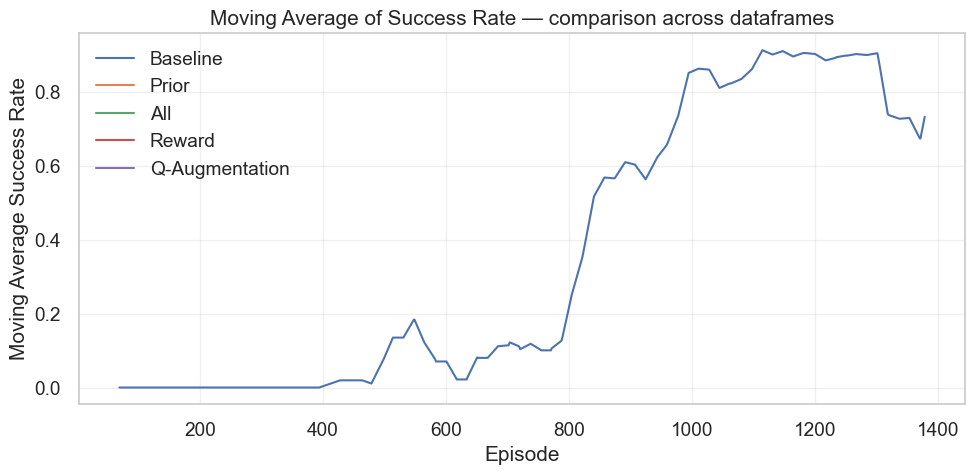

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ast

df1 = results_baseline
df2 = results_Prioritization
df3 = results_all
df4 = results_reward
df5 = results_q_aug

def get_avg_success_rate(df):
    all_rates = []
    for val in df['results_success_rate']:
        if isinstance(val, str):
            val = ast.literal_eval(val)
        all_rates.append(np.array(val))
    if not all_rates:
        return np.array([])
    max_len = max(len(r) for r in all_rates)
    padded = [np.pad(r, (0, max_len - len(r)), constant_values=np.nan) for r in all_rates]
    return np.nanmean(padded, axis=0)

def moving_average(arr, window_size=50):
    if len(arr) == 0:
        return arr
    arr = np.array(arr)
    ret = np.cumsum(np.nan_to_num(arr), dtype=float)
    ret[window_size:] = ret[window_size:] - ret[:-window_size]
    return ret[window_size - 1:] / window_size

avg1 = get_avg_success_rate(df1)
avg2 = get_avg_success_rate(df2)
avg3 = get_avg_success_rate(df3)
avg4 = get_avg_success_rate(df4)
avg5 = get_avg_success_rate(df5)

window = 70  # change as needed

ma1 = moving_average(avg1, window)
ma2 = moving_average(avg2, window)
ma3 = moving_average(avg3, window)
ma4 = moving_average(avg4, window)
ma5 = moving_average(avg5, window)
plt.figure(figsize=(10, 5))
plt.plot(range(window-1, window-1+len(ma1)), ma1, linewidth=1.5, label="Baseline")
plt.plot(range(window-1, window-1+len(ma2)), ma2, linewidth=1.5, label="Prior")
plt.plot(range(window-1, window-1+len(ma3)), ma3, linewidth=1.5, label="All")
plt.plot(range(window-1, window-1+len(ma4)), ma4, linewidth=1.5, label="Reward")
plt.plot(range(window-1, window-1+len(ma5)), ma5, linewidth=1.5, label="Q-Augmentation")

plt.xlabel("Episode")
plt.ylabel("Moving Average Success Rate")
plt.title(f"Moving Average of Success Rate — {visualization_file_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()